In [1]:
# Cell 1 — Imports and configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 2 — Load ML-ready dataset

DATA_PATH = Path("../data/processed/ml_ready_data.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Shape: (647367, 20)

Columns:
['State Name', 'District Name', 'Market Name', 'Variety', 'Group', 'Arrivals (Tonnes)', 'Min Price (Rs./Quintal)', 'Max Price (Rs./Quintal)', 'Modal Price (Rs./Quintal)', 'Reported Date', 'Commodity', 'Price_Lag_1', 'Price_Lag_7', 'Price_Rolling_7', 'Price_Rolling_30', 'Year', 'Month', 'Day', 'DayOfWeek', 'Price_Spread']


In [3]:
# Cell 3 — Inspect the ML-ready dataset

print("First 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDate range:")
print("Minimum:", df["Reported Date"].min())
print("Maximum:", df["Reported Date"].max())

print("\nUnique commodities:", df["Commodity"].nunique())
print("Unique markets:", df["Market Name"].nunique())
print("Unique states:", df["State Name"].nunique())

First 5 rows:


,State Name,District Name,Market Name,Variety,Group,Arrivals (Tonnes),Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Reported Date,Commodity,Price_Lag_1,Price_Lag_7,Price_Rolling_7,Price_Rolling_30,Year,Month,Day,DayOfWeek,Price_Spread
0,Andhra Pradesh,Kurnool,Adoni,Other,Spices,3.0,7009.0,9820.0,9300.0,2010-03-20,Ajwan,7500.0,2518.0,4323.714286,4323.714286,2010,3,20,5,2811.0
1,Andhra Pradesh,Kurnool,Adoni,Other,Spices,60.0,9101.0,13551.0,11500.0,2011-02-14,Ajwan,9300.0,4109.0,5292.571429,4945.750000,2011,2,14,0,4450.0
2,Andhra Pradesh,Kurnool,Adoni,Other,Spices,4.5,5002.0,6209.0,5500.0,2012-04-13,Ajwan,11500.0,4000.0,6348.428571,5674.000000,2012,4,13,4,1207.0
3,Andhra Pradesh,Kurnool,Adoni,Other,Spices,1.7,5129.0,5979.0,5400.0,2012-04-18,Ajwan,5500.0,3720.0,6562.714286,5656.600000,2012,4,18,2,850.0
4,Andhra Pradesh,Kurnool,Adoni,Other,Spices,3.0,5370.0,9509.0,8050.0,2012-07-30,Ajwan,5400.0,4100.0,6802.714286,5633.272727,2012,7,30,0,4139.0



Data types:
State Name                       str
District Name                    str
Market Name                      str
Variety                          str
Group                            str
Arrivals (Tonnes)            float64
Min Price (Rs./Quintal)      float64
Max Price (Rs./Quintal)      float64
Modal Price (Rs./Quintal)    float64
Reported Date                    str
Commodity                        str
Price_Lag_1                  float64
Price_Lag_7                  float64
Price_Rolling_7              float64
Price_Rolling_30             float64
Year                           int64
Month                          int64
Day                            int64
DayOfWeek                      int64
Price_Spread                 float64
dtype: object

Missing values:
State Name                   0
District Name                0
Market Name                  0
Variety                      0
Group                        0
Arrivals (Tonnes)            0
Min Price (Rs./Quintal)      0

In [4]:
# Cell 4 — Create next-price prediction target

df["Reported Date"] = pd.to_datetime(df["Reported Date"])

# Sort each commodity-market series chronologically
df = df.sort_values(
    ["Commodity", "Market Name", "Reported Date"]
).reset_index(drop=True)

# Target = next reported modal price
df["Target_Next_Price"] = (
    df.groupby(["Commodity", "Market Name"])["Modal Price (Rs./Quintal)"]
      .shift(-1)
)

# Remove rows where a future price is unavailable
before = len(df)

df = df.dropna(subset=["Target_Next_Price"]).copy()

after = len(df)

print("Target created successfully.")
print(f"Rows before: {before:,}")
print(f"Rows after : {after:,}")
print(f"Rows removed: {before - after:,}")

print("\nTarget statistics:")
print(df["Target_Next_Price"].describe())

Target created successfully.
Rows before: 647,367
Rows after : 620,798
Rows removed: 26,569

Target statistics:
count    6.207980e+05
mean     3.074370e+03
std      6.134421e+03
min      0.000000e+00
25%      1.200000e+03
50%      2.000000e+03
75%      3.680000e+03
max      1.400000e+06
Name: Target_Next_Price, dtype: float64


In [5]:
# Cell 5 — Define features and target

TARGET = "Target_Next_Price"

FEATURES = [
    "State Name",
    "District Name",
    "Market Name",
    "Variety",
    "Group",
    "Arrivals (Tonnes)",
    "Price_Lag_1",
    "Price_Lag_7",
    "Price_Rolling_7",
    "Price_Rolling_30",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Price_Spread"
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Features:", len(FEATURES))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used:")
for feature in FEATURES:
    print("-", feature)

print("\nTarget:", TARGET)

Features: 15
X shape: (620798, 15)
y shape: (620798,)

Features used:
- State Name
- District Name
- Market Name
- Variety
- Group
- Arrivals (Tonnes)
- Price_Lag_1
- Price_Lag_7
- Price_Rolling_7
- Price_Rolling_30
- Year
- Month
- Day
- DayOfWeek
- Price_Spread

Target: Target_Next_Price


In [6]:
# Cell 6 — Time-based train/test split

df = df.sort_values("Reported Date").reset_index(drop=True)

split_date = df["Reported Date"].quantile(0.80)

train_df = df[df["Reported Date"] < split_date].copy()
test_df = df[df["Reported Date"] >= split_date].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print("Split date:", split_date)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTrain date range:")
print(train_df["Reported Date"].min(), "to", train_df["Reported Date"].max())

print("\nTest date range:")
print(test_df["Reported Date"].min(), "to", test_df["Reported Date"].max())

Split date: 2021-10-04 00:00:00

Training set:
X_train: (496489, 15)
y_train: (496489,)

Test set:
X_test: (124309, 15)
y_test: (124309,)

Train date range:
2002-04-01 00:00:00 to 2021-10-03 00:00:00

Test date range:
2021-10-04 00:00:00 to 2024-02-01 00:00:00


In [7]:
# Cell 7 — Encode categorical features

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = [
    "State Name",
    "District Name",
    "Market Name",
    "Variety",
    "Group"
]

numeric_features = [
    "Arrivals (Tonnes)",
    "Price_Lag_1",
    "Price_Lag_7",
    "Price_Rolling_7",
    "Price_Rolling_30",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Price_Spread"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoding complete.")
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoding complete.
Encoded training shape: (496489, 3632)
Encoded test shape: (124309, 3632)


In [8]:
# Cell 8 — Baseline model

from sklearn.linear_model import Ridge

baseline_model = Ridge(alpha=1.0)

print("Training baseline model...")

baseline_model.fit(X_train_encoded, y_train)

print("Baseline model trained successfully.")

Training baseline model...
Baseline model trained successfully.


In [9]:
# Cell 9 — Baseline predictions and evaluation

print("Generating predictions...")

baseline_predictions = baseline_model.predict(X_test_encoded)

mae = mean_absolute_error(y_test, baseline_predictions)
rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
r2 = r2_score(y_test, baseline_predictions)

print("\n========== BASELINE RESULTS ==========")
print(f"MAE  : ₹{mae:,.2f}/quintal")
print(f"RMSE : ₹{rmse:,.2f}/quintal")
print(f"R²   : {r2:.4f}")

Generating predictions...

========== BASELINE RESULTS ==========
MAE  : ₹1,191.72/quintal
RMSE : ₹4,408.18/quintal
R²   : 0.4077


In [15]:
# Cell 10 — Fast stronger model

from sklearn.linear_model import SGDRegressor

MAX_TRAIN_ROWS = 150_000

# Take a representative training sample
rng = np.random.RandomState(42)

if X_train_encoded.shape[0] > MAX_TRAIN_ROWS:
    sample_idx = rng.choice(
        X_train_encoded.shape[0],
        size=MAX_TRAIN_ROWS,
        replace=False
    )

    X_train_model = X_train_encoded[sample_idx]
    y_train_model = y_train.iloc[sample_idx]
else:
    X_train_model = X_train_encoded
    y_train_model = y_train

print("Training rows:", X_train_model.shape[0])
print("Features:", X_train_model.shape[1])

strong_model = SGDRegressor(
    loss="huber",
    max_iter=1000,
    tol=1e-3,
    alpha=0.0001,
    random_state=42
)

print("Training stronger model...")

strong_model.fit(X_train_model, y_train_model)

print("Stronger model trained successfully.")

Training rows: 150000
Features: 3632
Training stronger model...
Stronger model trained successfully.


In [16]:
# Cell 11 — Stronger model evaluation

print("Generating predictions...")

strong_predictions = strong_model.predict(X_test_encoded)

strong_mae = mean_absolute_error(y_test, strong_predictions)
strong_rmse = np.sqrt(mean_squared_error(y_test, strong_predictions))
strong_r2 = r2_score(y_test, strong_predictions)

print("\n========== STRONGER MODEL RESULTS ==========")
print(f"MAE  : ₹{strong_mae:,.2f}/quintal")
print(f"RMSE : ₹{strong_rmse:,.2f}/quintal")
print(f"R²   : {strong_r2:.4f}")

Generating predictions...

========== STRONGER MODEL RESULTS ==========
MAE  : ₹1,171.23/quintal
RMSE : ₹5,534.26/quintal
R²   : 0.0664


In [17]:
# Cell 12 — Compare model performance

comparison = pd.DataFrame({
    "Model": ["Ridge", "SGD Huber"],
    "MAE": [mae, strong_mae],
    "RMSE": [rmse, strong_rmse],
    "R2": [r2, strong_r2]
})

display(comparison)

print("\nSelected model: Ridge")
print(f"Reason: Higher R² ({r2:.4f}) and lower RMSE (₹{rmse:,.2f})")

,Model,MAE,RMSE,R2
0,Ridge,1191.717447,4408.177907,0.407667
1,SGD Huber,1171.230418,5534.262581,0.066386



Selected model: Ridge
Reason: Higher R² (0.4077) and lower RMSE (₹4,408.18)


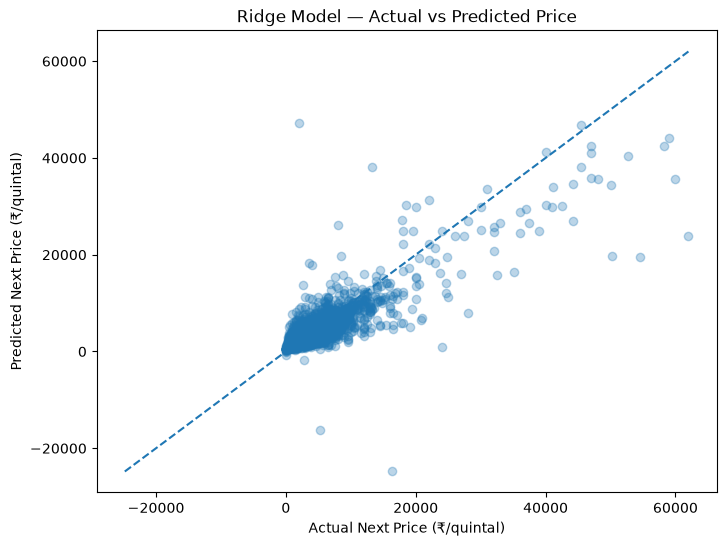

In [18]:
# Cell 13 — Actual vs Predicted Price

plt.figure(figsize=(8, 6))

# Plot only a sample so the visualization stays readable
plot_sample = min(5000, len(y_test))

rng = np.random.RandomState(42)
plot_idx = rng.choice(len(y_test), plot_sample, replace=False)

plt.scatter(
    y_test.iloc[plot_idx],
    baseline_predictions[plot_idx],
    alpha=0.3
)

# Perfect prediction line
min_price = min(
    y_test.iloc[plot_idx].min(),
    baseline_predictions[plot_idx].min()
)

max_price = max(
    y_test.iloc[plot_idx].max(),
    baseline_predictions[plot_idx].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Next Price (₹/quintal)")
plt.ylabel("Predicted Next Price (₹/quintal)")
plt.title("Ridge Model — Actual vs Predicted Price")
plt.show()

In [19]:
# Cell 14 — Save model and preprocessing pipeline

import joblib

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(baseline_model, MODEL_DIR / "ridge_price_model.pkl")
joblib.dump(preprocessor, MODEL_DIR / "price_preprocessor.pkl")

print("========== MODEL SAVED ==========")
print("Model:", MODEL_DIR / "ridge_price_model.pkl")
print("Preprocessor:", MODEL_DIR / "price_preprocessor.pkl")

========== MODEL SAVED ==========
Model: ..\models\ridge_price_model.pkl
Preprocessor: ..\models\price_preprocessor.pkl


In [20]:
# Cell 15 — Test a real prediction

sample = X_test.iloc[[0]]

# Transform the sample using the saved preprocessing pipeline
sample_encoded = preprocessor.transform(sample)

# Predict next modal price
sample_prediction = baseline_model.predict(sample_encoded)[0]

print("========== SAMPLE PRICE PREDICTION ==========")
print(f"Commodity : {test_df.iloc[0]['Commodity'] if 'test_df' in globals() else 'From test data'}")
print(f"Predicted next price: ₹{sample_prediction:,.2f}/quintal")

========== SAMPLE PRICE PREDICTION ==========
Commodity : Apple
Predicted next price: ₹9,274.49/quintal


In [21]:
# Cell 16 — Final model summary

print("========== PRICE PREDICTION MODEL ==========")
print("Selected Model : Ridge Regression")
print(f"Training Rows  : {len(y_train):,}")
print(f"Testing Rows   : {len(y_test):,}")
print(f"MAE            : ₹{mae:,.2f}/quintal")
print(f"RMSE           : ₹{rmse:,.2f}/quintal")
print(f"R²             : {r2:.4f}")

print("\n========== SAMPLE PREDICTION ==========")
print(f"Predicted Next Price: ₹{sample_prediction:,.2f}/quintal")

print("\nModel files saved:")
print("- ridge_price_model.pkl")
print("- price_preprocessor.pkl")

========== PRICE PREDICTION MODEL ==========
Selected Model : Ridge Regression
Training Rows  : 496,489
Testing Rows   : 124,309
MAE            : ₹1,191.72/quintal
RMSE           : ₹4,408.18/quintal
R²             : 0.4077

========== SAMPLE PREDICTION ==========
Predicted Next Price: ₹9,274.49/quintal

Model files saved:
- ridge_price_model.pkl
- price_preprocessor.pkl
